In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay

#Cargamos el dataset Iris
iris = datasets.load_iris()
#Usamos solo las columnas: longitud de sépalo y longitud de pétalo
X = iris.data[:, [0, 2]] 
y = iris.target

# Filtramos solo las clases Versicolor (clase 1) vs Virgínica (clase 2)
mask_b = (y == 1) | (y == 2)
X_b, y_b = X[mask_b], y[mask_b]


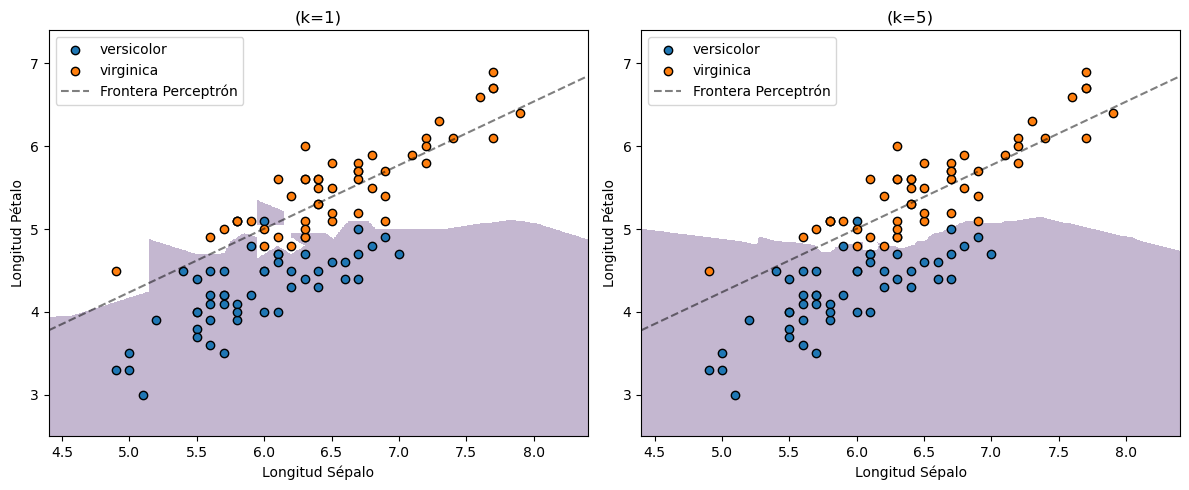

In [3]:
#Calculo perceptrones (fronteras de decisión) y knn, y hago los dibujos
cmap_light = ListedColormap(['#C4B7D0', '#FFFFFF'])

fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(12, 5))

def plot_knn(ax, k_val, X_data, y_data, title):
    clf_knn = KNeighborsClassifier(n_neighbors=k_val).fit(X_data, y_data)
    #Creamos una malla para el fondo
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
   
    disp = DecisionBoundaryDisplay.from_estimator(
        clf_knn,
        X_data,
        response_method="predict",
        plot_method="pcolormesh",
        ax=ax,
        cmap=cmap_light,
        alpha=1.0, # Color sólido para que la mancha se vea clara
        shading="auto",
        grid_resolution=500
    )

    # Dibujamos los puntos originales:
    for i, label in enumerate(np.unique(y_data)):
        ax.scatter(X_data[y_data==label, 0], X_data[y_data==label, 1], 
                   label=iris.target_names[label], 
                   edgecolors='k')
    
    # Dibujamos la frontera lineal del Perceptrón para comparar 
    perc = Perceptron(max_iter=1000,tol=1e-6, random_state=20).fit(X_data, y_data)
    w, b = perc.coef_[0], perc.intercept_[0]
    xx = np.linspace(x_min, x_max, 100)
    yy = -(w[0] * xx + b) / w[1]
    ax.plot(xx, yy, 'k--', alpha=0.5, label='Frontera Perceptrón', zorder=3)
    ax.set_title(title)
    ax.set_xlabel('Longitud Sépalo')
    ax.set_ylabel('Longitud Pétalo')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()


plot_knn(ax1, 1, X_b, y_b, "(k=1)")
plot_knn(ax2, 5, X_b, y_b, "(k=5)")

plt.tight_layout()
plt.show()

